In [ ]:
# Task 1: NAV Trend Analysis
#Daily NAV trends of 40 mutual fund schemes (2022–2025)

In [15]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.head())
print(nav.columns.tolist())
print(nav.shape)



   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
['amfi_code', 'date', 'nav']
(46000, 3)


In [16]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav["amfi_code"].nunique())

fund_119551 = nav[nav["amfi_code"] == 119551]
print(fund_119551.head())

40
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


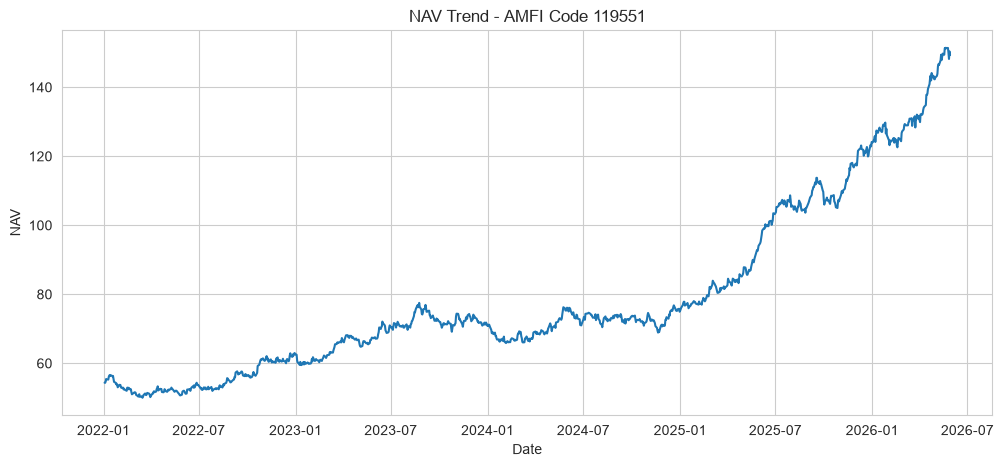

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    fund_119551["date"],
    fund_119551["nav"]
)

plt.title("NAV Trend - AMFI Code 119551")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

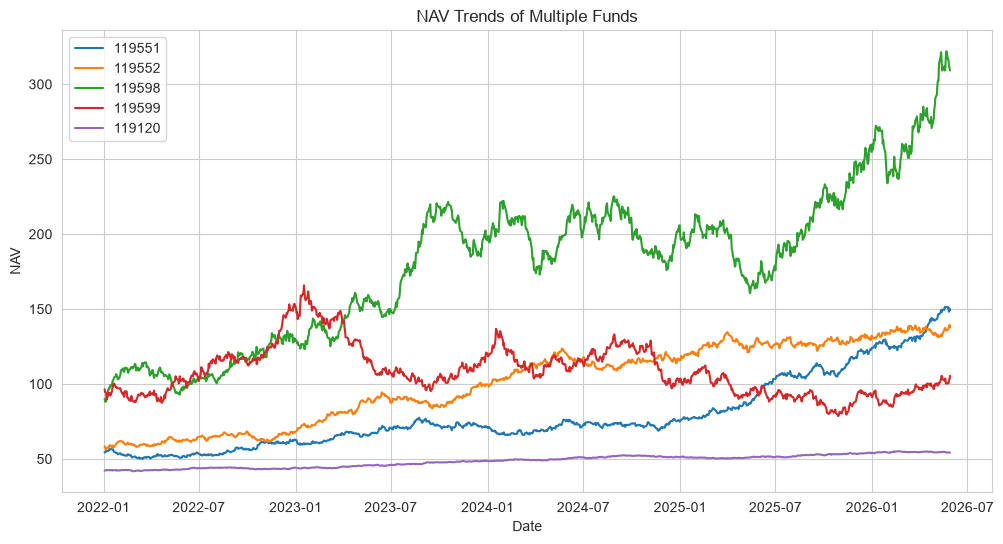

In [69]:
plt.figure(figsize=(12,6))

for code in nav["amfi_code"].unique()[:5]:
    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

plt.title("NAV Trends of Multiple Funds")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.show()

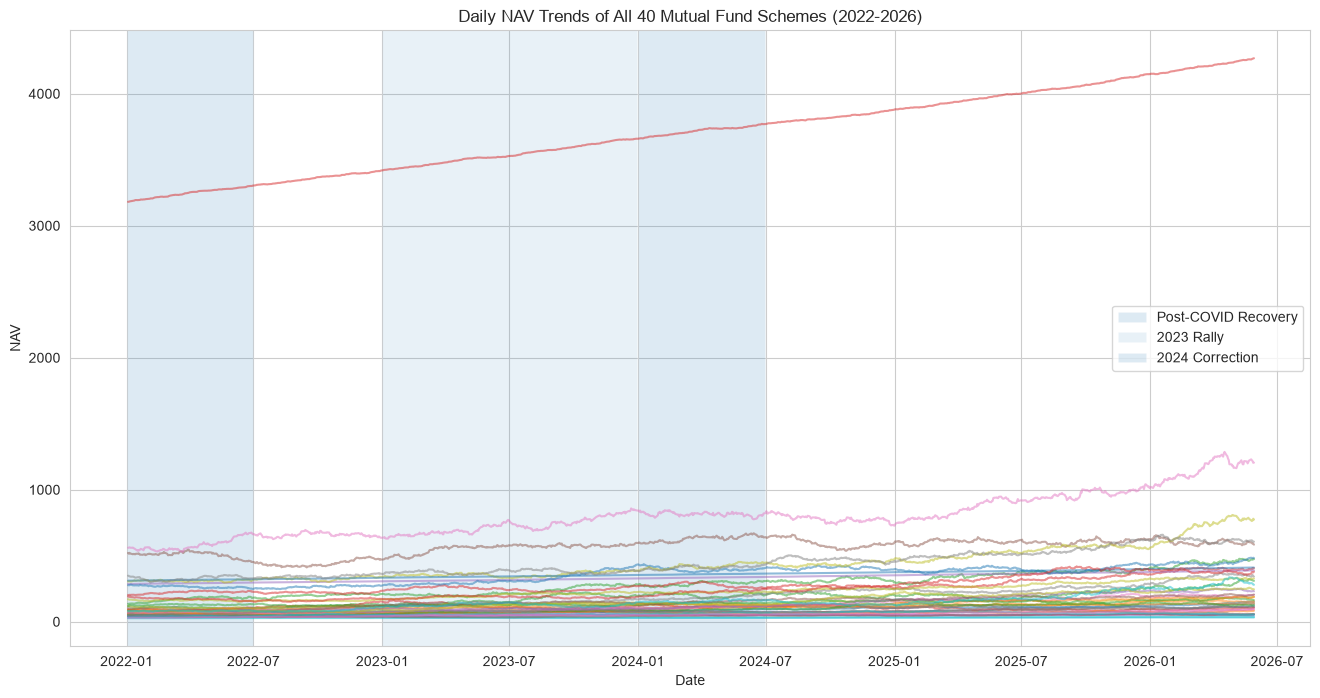

In [72]:
plt.figure(figsize=(16,8))

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        alpha=0.5
    )

plt.axvspan(
    pd.to_datetime("2022-01-01"),
    pd.to_datetime("2022-06-30"),
    alpha=0.15,
    label="Post-COVID Recovery"
)

plt.axvspan(
    pd.to_datetime("2023-01-01"),
    pd.to_datetime("2023-12-31"),
    alpha=0.10,
    label="2023 Rally"
)

plt.axvspan(
    pd.to_datetime("2024-01-01"),
    pd.to_datetime("2024-06-30"),
    alpha=0.15,
    label="2024 Correction"
)

plt.title("Daily NAV Trends of All 40 Mutual Fund Schemes (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

In [ ]:
# Task 2: AUM Growth Analysis
#AUM comparison of major fund houses (2022–2025)

In [17]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.head())
print(aum.columns.tolist())
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
print(aum.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
(90, 6)


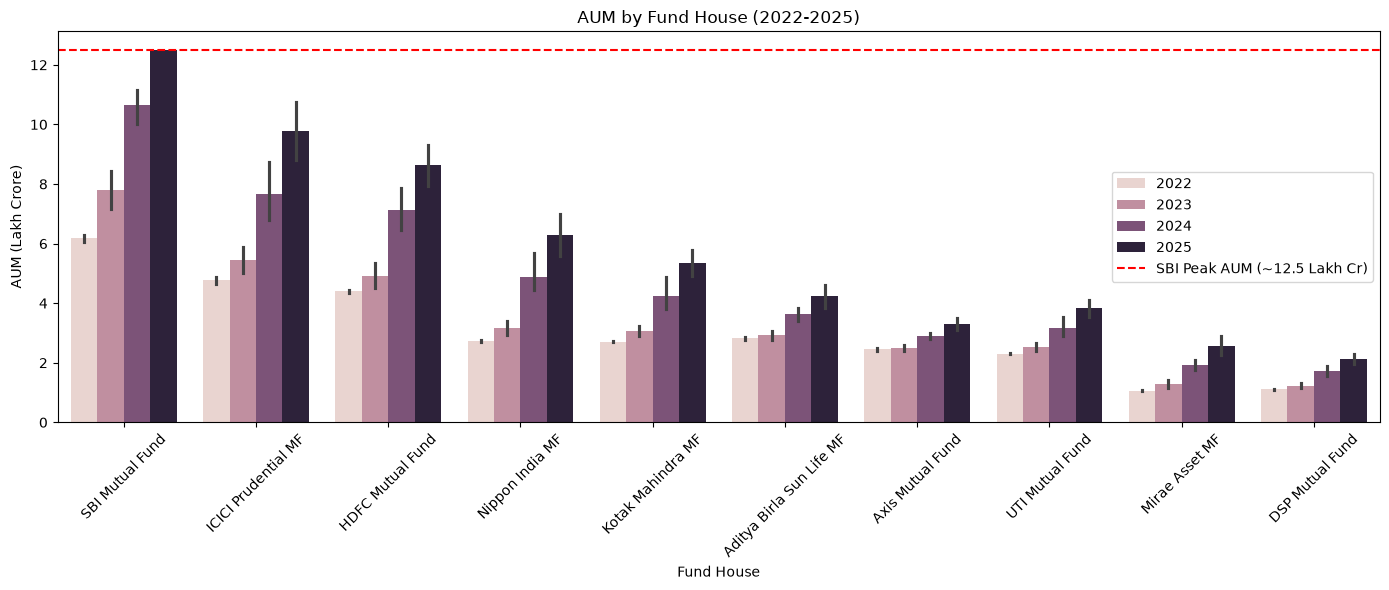

Observation: SBI Mutual Fund remained the largest AMC and crossed approximately 12.5 lakh crore AUM.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.axhline(
    y=12.5,
    color="red",
    linestyle="--",
    label="SBI Peak AUM (~12.5 Lakh Cr)"
)

plt.legend()

plt.show()

print("Observation: SBI Mutual Fund remained the largest AMC and crossed approximately 12.5 lakh crore AUM.")

In [17]:
latest_date = aum["date"].max()

latest_aum = aum[aum["date"] == latest_date]

latest_aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168


In [18]:
top10 = latest_aum.sort_values(
    by="aum_crore",
    ascending=False
).head(10)

top10

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
88,2025-12-31,Mirae Asset MF,2.90,290000,56
89,2025-12-31,DSP Mutual Fund,2.30,230000,88


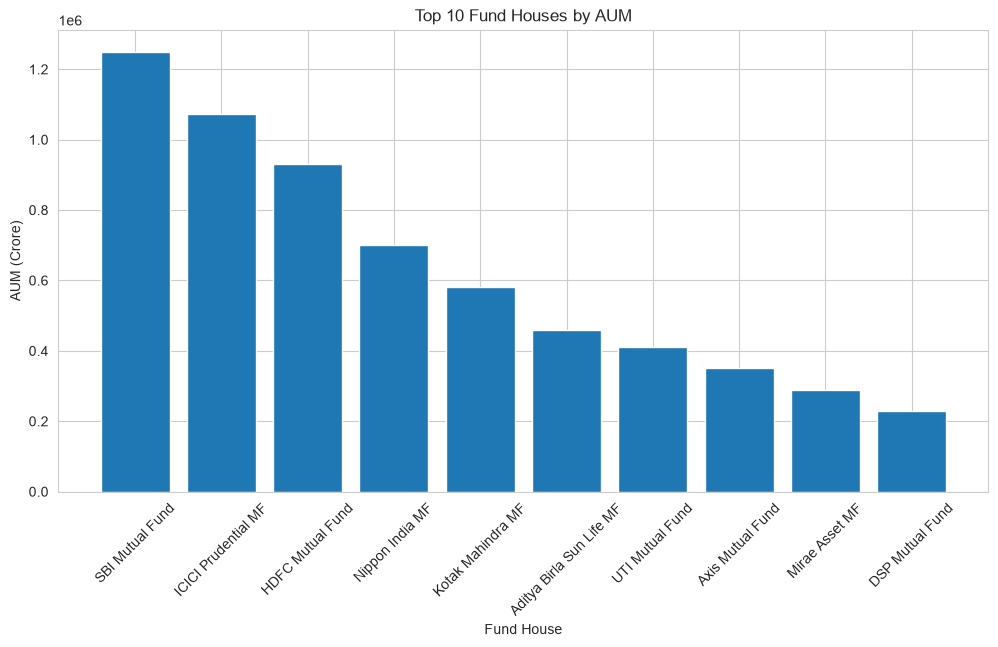

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["fund_house"],
    top10["aum_crore"]
)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Task 3: SIP Inflow Trend Analysis
#Monthly SIP inflow growth and ₹31,002 Cr milestone


In [24]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns.tolist())
print(sip.shape)

sip["month"] = pd.to_datetime(sip["month"])

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
(48, 6)


In [27]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.show()

In [28]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [29]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="31,002 Cr Milestone",
    showarrow=True
)

fig.show()

In [ ]:
# Task 4: Category-wise Inflow Heatmap
#Analysis of net inflows across mutual fund categories

In [32]:
import pandas as pd

cat = pd.read_csv("../data/raw/05_category_inflows.csv")

cat["month"] = pd.to_datetime(cat["month"])

In [34]:
pivot = cat.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

pivot.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


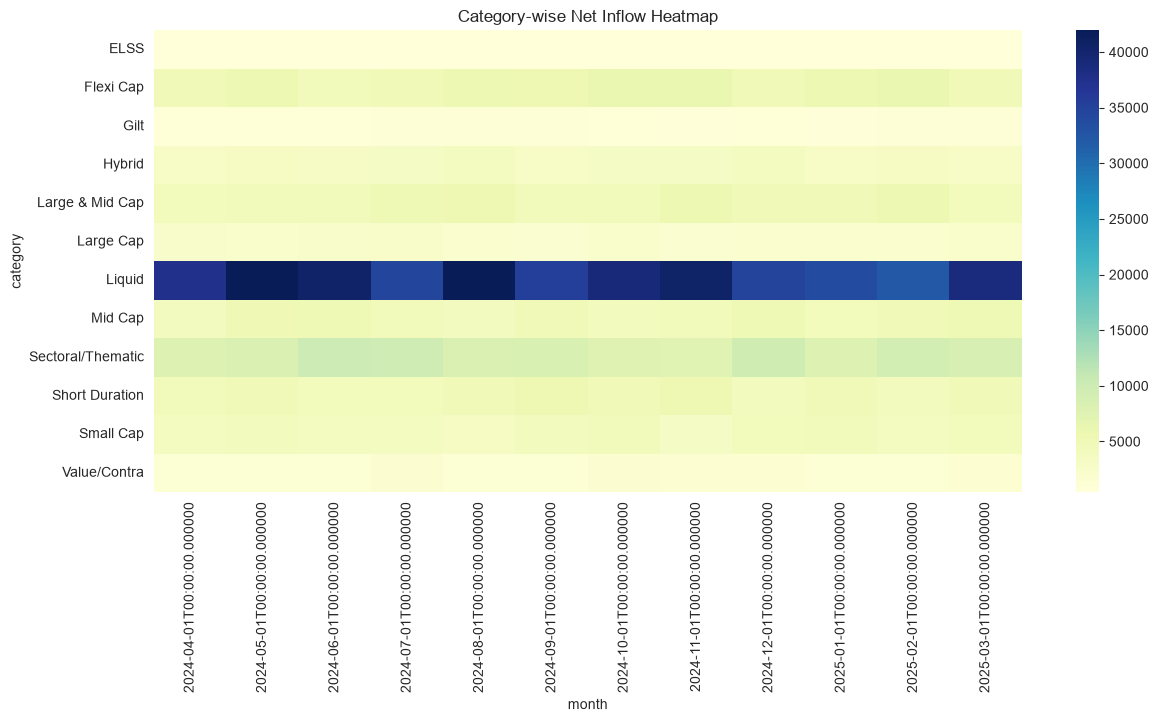

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.show()

In [ ]:
# Task 5: Investor Demographics Analysis
#Age group distribution and SIP investment behavior

In [19]:
inv = pd.read_csv("../data/raw/08_investor_transactions.csv")
age_counts = inv["age_group"].value_counts()

print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


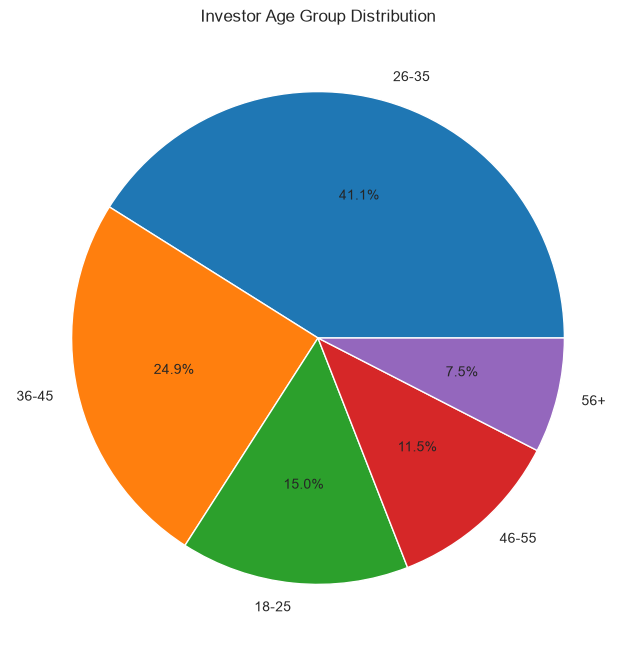

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter SIP transactions
sip_txn = inv[inv["transaction_type"] == "SIP"]

# Create box plot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

In [ ]:
# Task 6: Geographic Distribution Analysis
#State-wise SIP investments and T30 vs B30 participation

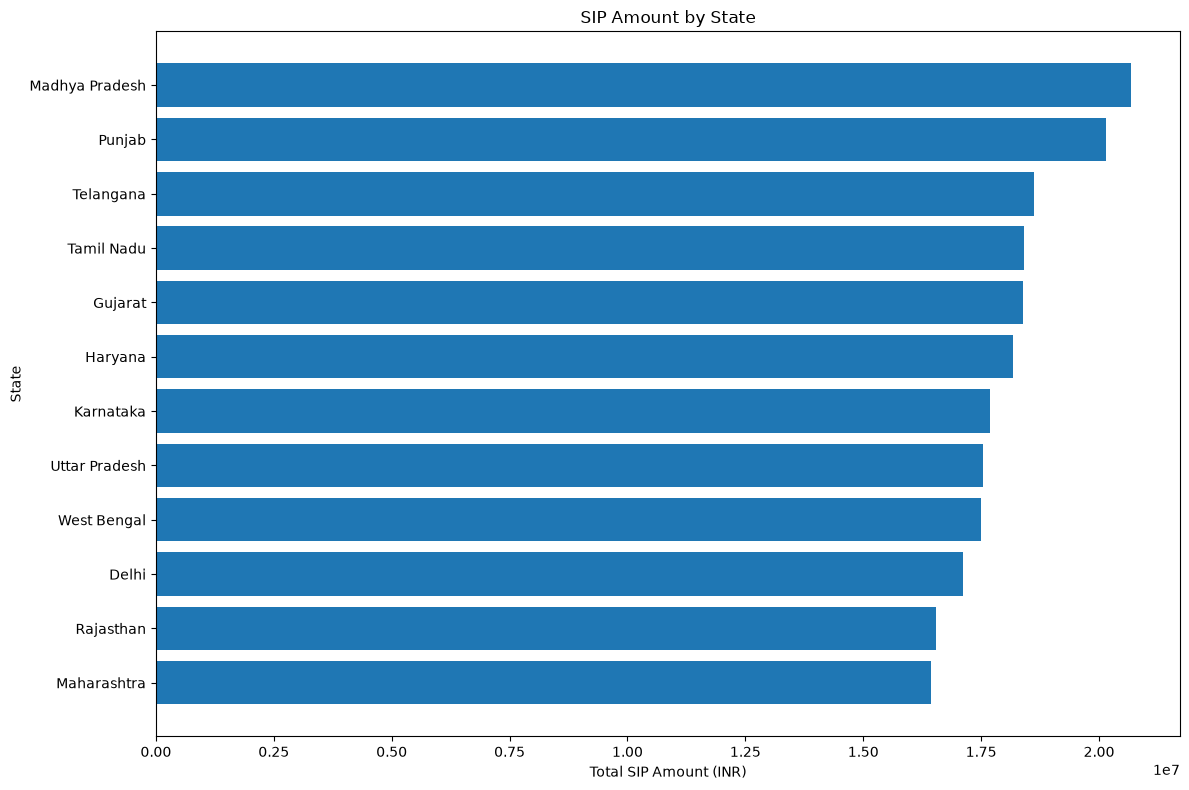

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
inv = pd.read_csv("../data/raw/08_investor_transactions.csv")

# Keep only SIP transactions
sip_data = inv[inv["transaction_type"] == "SIP"]

# Total SIP amount by state
state_sip = (
    sip_data.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

# Plot horizontal bar chart
plt.figure(figsize=(12, 8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

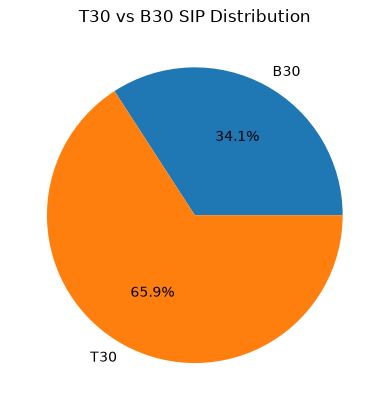

In [10]:
tier_data = inv.groupby("city_tier")["amount_inr"].sum()

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 SIP Distribution")
plt.show()

In [43]:
state_counts = inv["state"].value_counts()

print(state_counts.head(10))

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64


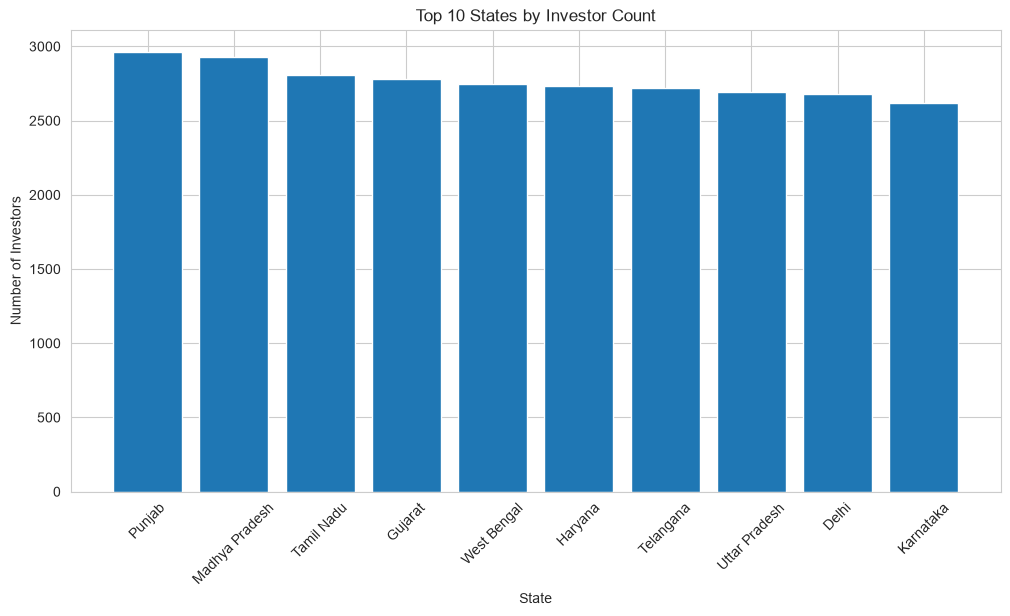

In [44]:
import matplotlib.pyplot as plt

top_states = state_counts.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_states.index,
    top_states.values
)

plt.title("Top 10 States by Investor Count")
plt.xlabel("State")
plt.ylabel("Number of Investors")

plt.xticks(rotation=45)

plt.show()

In [45]:
tier_counts = inv["city_tier"].value_counts()

print(tier_counts)

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


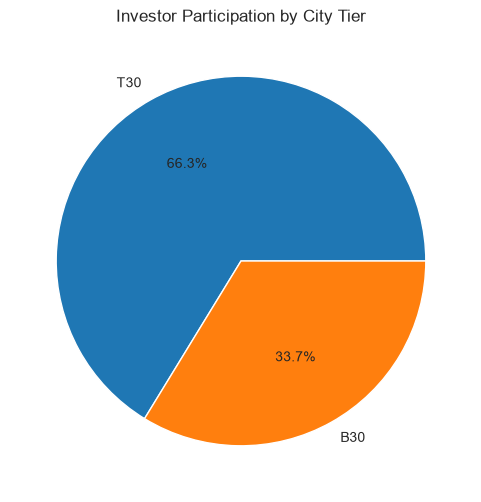

In [46]:
plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Participation by City Tier")

plt.show()

In [47]:
city_amount = inv.groupby(
    "city"
)["amount_inr"].sum().sort_values(
    ascending=False
).head(10)

print(city_amount)

city
Kolkata       297182514
Hyderabad     290219284
Gurugram      223778908
Coimbatore    170345165
Bhopal        165606495
Ahmedabad     160916535
Amritsar      159315652
Chandigarh    156464807
Jaipur        153768697
Faridabad     148078011
Name: amount_inr, dtype: int64


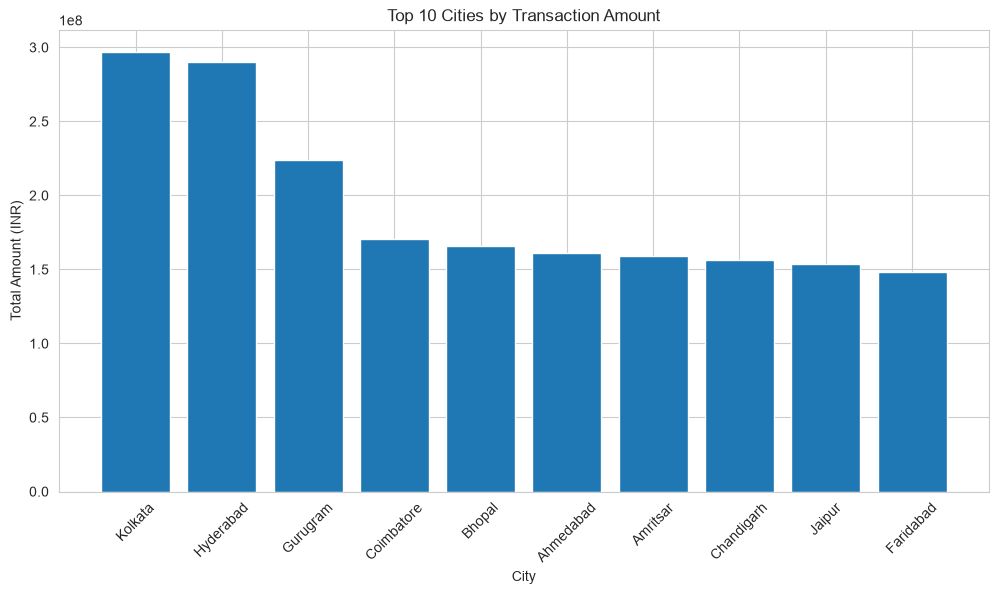

In [48]:
plt.figure(figsize=(12,6))

plt.bar(
    city_amount.index,
    city_amount.values
)

plt.title("Top 10 Cities by Transaction Amount")
plt.xlabel("City")
plt.ylabel("Total Amount (INR)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Task 7: Folio Growth Analysis # Task 7: Folio Growth Analysis
#Growth in mutual fund folios from 2022 to 2025

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


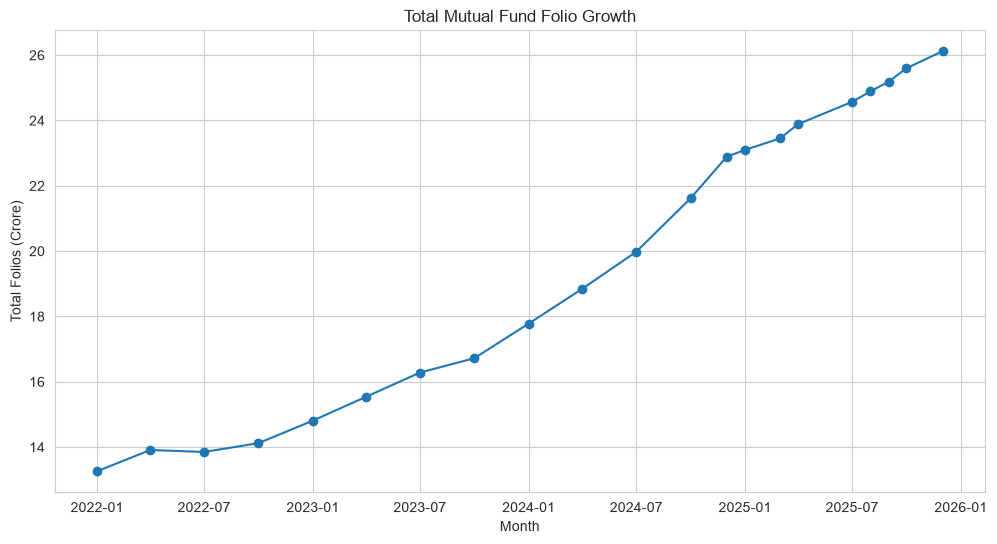

In [51]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Total Mutual Fund Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

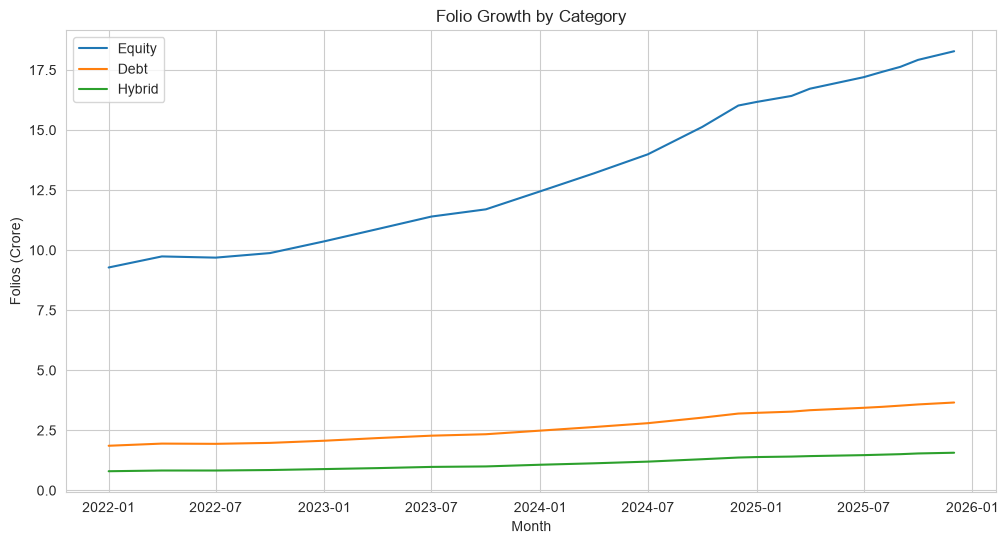

In [52]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    label="Equity"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    label="Debt"
)

plt.plot(
    folio["month"],
    folio["hybrid_folios_crore"],
    label="Hybrid"
)

plt.title("Folio Growth by Category")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()

plt.grid(True)

plt.show()

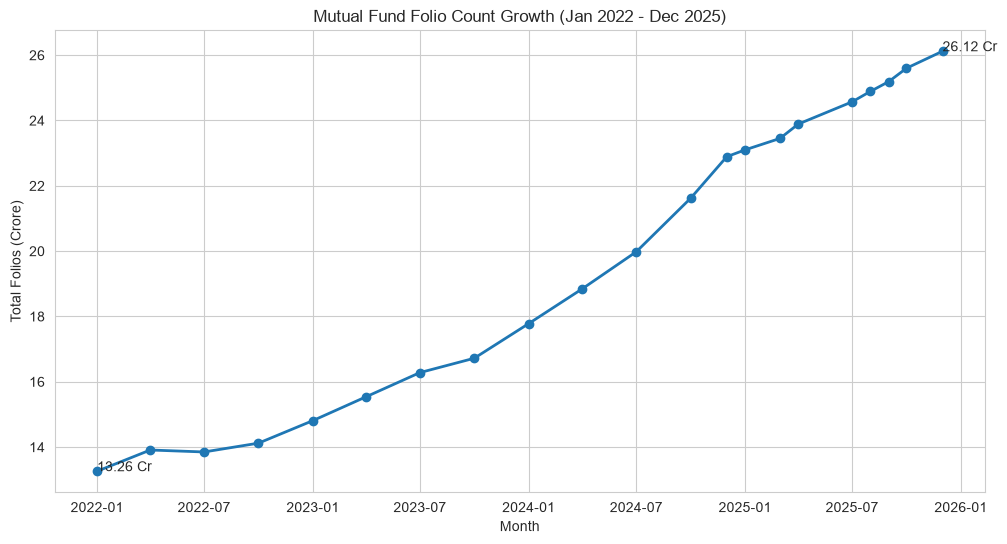

Starting Folios: 13.26
Ending Folios: 26.12


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Mutual Fund Folio Count Growth (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.grid(True)

plt.show()

print("Starting Folios:", folio["total_folios_crore"].iloc[0])
print("Ending Folios:", folio["total_folios_crore"].iloc[-1])

In [ ]:
# Task 8: Correlation Matrix Analysis
#Correlation of NAV returns across 10 selected funds

In [11]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [12]:
selected_funds = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(selected_funds)]

In [13]:
nav_pivot = nav10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(nav_pivot.head())

amfi_code     100016   100025    100033   119120   119551   119552   119598  \
date                                                                          
2022-01-03  520.4608  26.3169  107.3758  42.1391  54.3856  58.4174  89.8738   
2022-01-04  515.0971  26.2234  105.9447  42.2508  54.3474  57.3480  88.5495   
2022-01-05  521.7239  26.2221  105.4800  42.4374  54.6869  57.0552  88.0925   
2022-01-06  515.7880  26.1728  104.9350  42.5901  55.4550  56.4224  88.5175   
2022-01-07  515.1639  26.2261  104.3318  42.4851  55.3692  57.2750  91.4235   

amfi_code    119599    125497    125498  
date                                     
2022-01-03  96.4565  560.1443  117.5969  
2022-01-04  94.6512  560.7052  117.0077  
2022-01-05  94.5436  563.0884  116.4011  
2022-01-06  93.7944  561.0675  116.0861  
2022-01-07  89.6438  559.5420  114.6164  


In [14]:
returns = nav_pivot.pct_change().dropna()

print(returns.head())

amfi_code     100016    100025    100033    119120    119551    119552  \
date                                                                     
2022-01-04 -0.010306 -0.003553 -0.013328  0.002651 -0.000702 -0.018306   
2022-01-05  0.012865 -0.000050 -0.004386  0.004416  0.006247 -0.005106   
2022-01-06 -0.011377 -0.001880 -0.005167  0.003598  0.014045 -0.011091   
2022-01-07 -0.001210  0.002036 -0.005748 -0.002465 -0.001547  0.015111   
2022-01-10 -0.008639  0.006791  0.006277 -0.000353 -0.001548  0.009465   

amfi_code     119598    119599    125497    125498  
date                                                
2022-01-04 -0.014735 -0.018716  0.001001 -0.005010  
2022-01-05 -0.005161 -0.001137  0.004250 -0.005184  
2022-01-06  0.004824 -0.007924 -0.003589 -0.002706  
2022-01-07  0.032830 -0.044252 -0.002719 -0.012660  
2022-01-10  0.051113  0.033761  0.003057 -0.019536  


In [15]:
corr_matrix = returns.corr()

print(corr_matrix)

amfi_code    100016    100025    100033    119120    119551    119552  \
amfi_code                                                               
100016     1.000000  0.045567 -0.000006 -0.022521  0.040858  0.013663   
100025     0.045567  1.000000  0.002150 -0.040884  0.017017 -0.002803   
100033    -0.000006  0.002150  1.000000 -0.007166 -0.015559 -0.027471   
119120    -0.022521 -0.040884 -0.007166  1.000000  0.021601 -0.004003   
119551     0.040858  0.017017 -0.015559  0.021601  1.000000 -0.006819   
119552     0.013663 -0.002803 -0.027471 -0.004003 -0.006819  1.000000   
119598    -0.030296 -0.065019  0.006659  0.018423  0.024409  0.020754   
119599    -0.000007 -0.034061 -0.028323  0.017795 -0.072559 -0.042415   
125497     0.047139  0.011326 -0.025137 -0.010542  0.016469  0.027796   
125498    -0.016089 -0.025505 -0.011916 -0.016315  0.030454 -0.052299   

amfi_code    119598    119599    125497    125498  
amfi_code                                          
100016    -0.030296

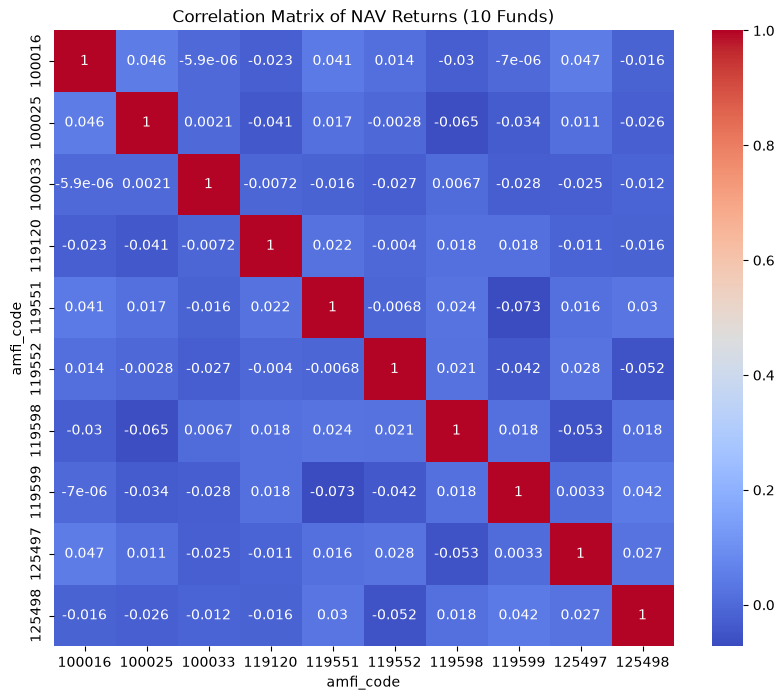

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of NAV Returns (10 Funds)")

plt.show()

In [ ]:
# Task 9: Sector Allocation Analysis
#Sector-wise portfolio allocation and exposure analysis

In [20]:
import pandas as pd

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
sector_alloc = holdings.groupby(
    "sector"
)["weight_pct"].sum().sort_values(
    ascending=False
)

print(sector_alloc)


sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


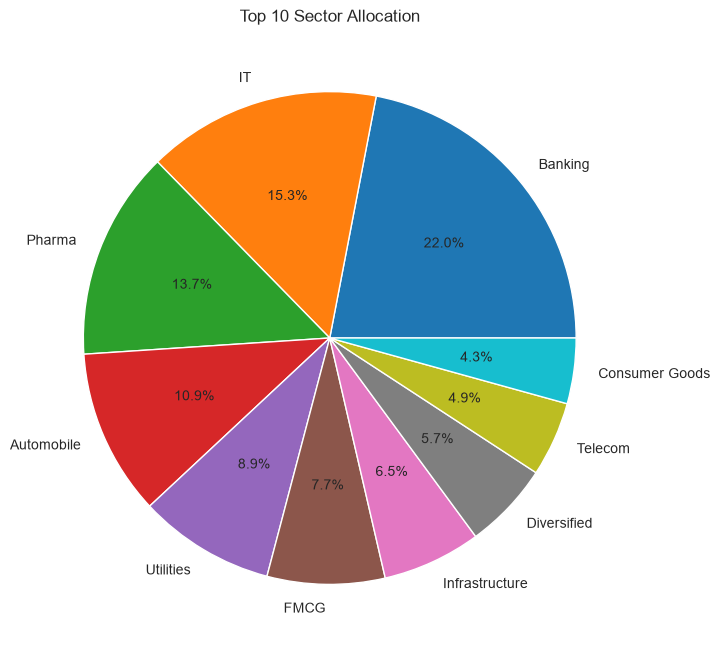

In [66]:
top10 = sector_alloc.head(10)

plt.figure(figsize=(10,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%"
)

plt.title("Top 10 Sector Allocation")

plt.show()